Лабораторная работа № 4.

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import mpl_toolkits.mplot3d
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm
import time
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

Подготовка датасета.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
dataset = pd.read_csv('/content/drive/MyDrive/database_gas.csv')
print("Информация о датасете:")
dataset.head()

Информация о датасете:


,timestamp,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,2019-11-06 11:37:13.038174+01:00,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0
1,2019-11-06 11:37:32.744996+01:00,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0
2,2019-11-06 11:37:53.018087+01:00,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0
3,2019-11-06 11:38:13.093151+01:00,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0
4,2019-11-06 11:38:33.032832+01:00,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0


In [8]:
vals = dataset["timestamp"].unique()
vals

array(['2019-11-06 11:37:13.038174+01:00',
       '2019-11-06 11:37:32.744996+01:00',
       '2019-11-06 11:37:53.018087+01:00', ...,
       '2020-02-13 11:57:33.983249+01:00',
       '2020-02-13 11:57:54.058349+01:00',
       '2020-02-13 11:58:14.014336+01:00'], dtype=object)

In [9]:
cols_for_clusters = ['temperature','humidity','CO2CosIRValue','CO2MG811Value','MOX1','MOX2','MOX3','MOX4','COValue']
df= dataset[cols_for_clusters].copy()
df.head()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0
1,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0
2,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0
3,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0
4,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0


In [10]:
X = df
y, yvals = pd.factorize(dataset["timestamp"])
print(f"Уникальные классы: {yvals}")
print(f"Закодированные метки (первые 5): {y[:5]}")

Уникальные классы: Index(['2019-11-06 11:37:13.038174+01:00', '2019-11-06 11:37:32.744996+01:00',
       '2019-11-06 11:37:53.018087+01:00', '2019-11-06 11:38:13.093151+01:00',
       '2019-11-06 11:38:33.032832+01:00', '2019-11-06 11:38:52.976443+01:00',
       '2019-11-06 11:39:12.883211+01:00', '2019-11-06 11:39:32.839508+01:00',
       '2019-11-06 11:39:53.003425+01:00', '2019-11-06 11:40:12.986268+01:00',
       ...
       '2020-02-13 11:55:13.930613+01:00', '2020-02-13 11:55:33.951730+01:00',
       '2020-02-13 11:55:54.065586+01:00', '2020-02-13 11:56:14.043796+01:00',
       '2020-02-13 11:56:34.223559+01:00', '2020-02-13 11:56:53.929978+01:00',
       '2020-02-13 11:57:14.204458+01:00', '2020-02-13 11:57:33.983249+01:00',
       '2020-02-13 11:57:54.058349+01:00', '2020-02-13 11:58:14.014336+01:00'],
      dtype='object', length=416153)
Закодированные метки (первые 5): [0 1 2 3 4]


K-Means.

Отображаем 500 случайных точек из 416153


/tmp/ipykernel_16419/1366245299.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


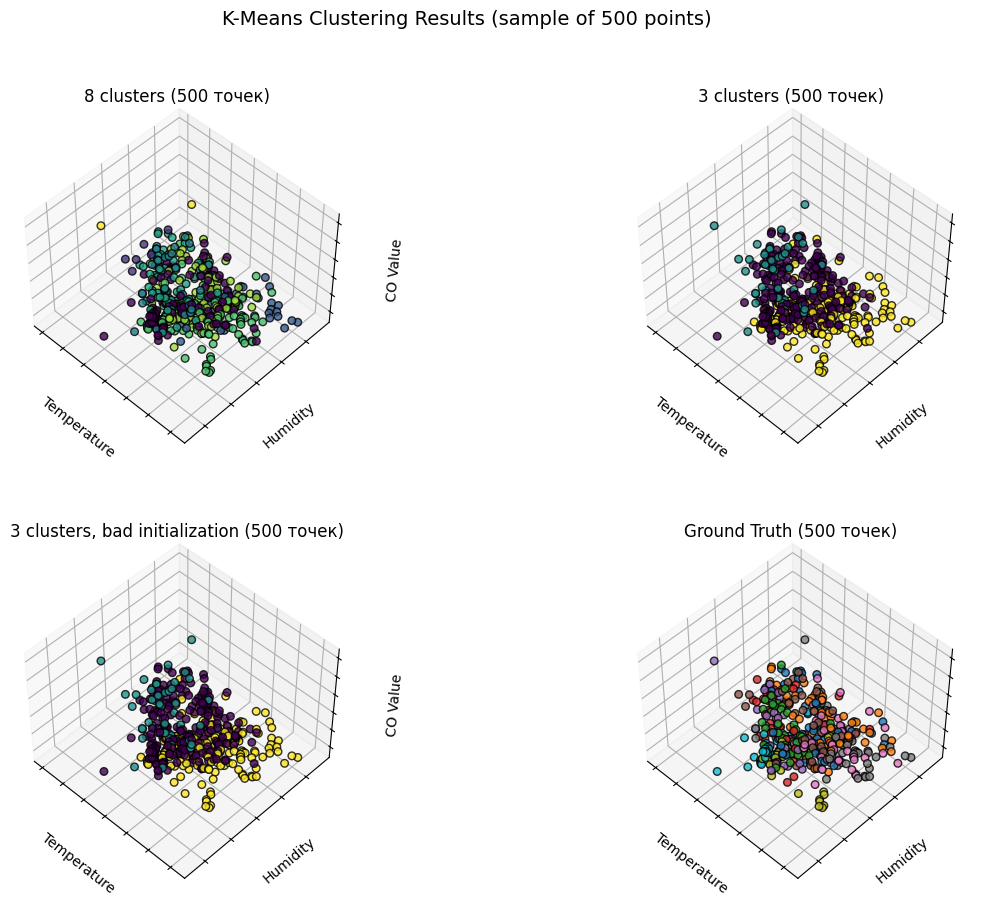


Статистика:
  Всего точек в датасете: 416153
  Отображено точек: 500 (0.1%)


In [27]:
MAX_POINTS = 500
if len(X) > MAX_POINTS:
    sample_idx = np.random.choice(len(X), MAX_POINTS, replace=False)
    X_sample = X.iloc[sample_idx] if hasattr(X, 'iloc') else X[sample_idx]
    y_sample = y[sample_idx]
    print(f"Отображаем {MAX_POINTS} случайных точек из {len(X)}")
else:
    X_sample = X
    y_sample = y
    print(f"Отображаем все {len(X)} точек")
estimators = [
    ("k_means_8", KMeans(n_clusters=8, random_state=42)),
    ("k_means_3", KMeans(n_clusters=3, random_state=42)),
    ("k_means_bad_init", KMeans(n_clusters=3, n_init=1, init="random", random_state=42)),
]
fig = plt.figure(figsize=(14, 10))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels_sample = est.labels_[sample_idx] if len(X) > MAX_POINTS else est.labels_
    scatter = ax.scatter(
        X_sample["temperature"],
        X_sample["humidity"],
        X_sample["COValue"],
        c=labels_sample.astype(float),
        edgecolor="k",
        s=30,
        alpha=0.8,
        cmap='viridis'
    )
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Temperature", fontsize=10)
    ax.set_ylabel("Humidity", fontsize=10)
    ax.set_zlabel("CO Value", fontsize=10)
    ax.set_title(f"{title} ({len(X_sample)} точек)", fontsize=12)
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)
unique_timestamps = np.unique(dataset["timestamp"])[:5]
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_timestamps)))
for i, name in enumerate(unique_timestamps):
    mask = dataset["timestamp"].iloc[sample_idx] == name if len(X) > MAX_POINTS else dataset["timestamp"] == name
    ds_sample = X_sample[mask]
    if len(ds_sample) > 0:
        if len(ds_sample) > 5:
            ax.text3D(
                ds_sample["temperature"].mean(),
                ds_sample["humidity"].mean(),
                ds_sample["COValue"].mean(),
                f"Class {i+1}",
                horizontalalignment="center",
                bbox=dict(alpha=0.3, edgecolor="w", facecolor=colors[i]),
                fontsize=9,
                color='white'
            )
scatter = ax.scatter(
    X_sample["temperature"],
    X_sample["humidity"],
    X_sample["COValue"],
    c=y_sample[:len(X_sample)],
    edgecolor="k",
    s=30,
    alpha=0.8,
    cmap='tab10'
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Temperature", fontsize=10)
ax.set_ylabel("Humidity", fontsize=10)
ax.set_zlabel("CO Value", fontsize=10)
ax.set_title(f"Ground Truth ({len(X_sample)} точек)", fontsize=12)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle(f"K-Means Clustering Results (sample of {len(X_sample)} points)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()
print(f"\nСтатистика:")
print(f"  Всего точек в датасете: {len(X)}")
print(f"  Отображено точек: {len(X_sample)} ({len(X_sample)/len(X)*100:.1f}%)")

Метрики.

In [29]:
n_clusters = np.arange(2, 21)

ЗАПУСК ОПТИМИЗИРОВАННОГО АНАЛИЗА...

АНАЛИЗ K-MEANS (только Silhouette)
Размер датасета: 416153 строк × 9 признаков
Используем выборку 5000 точек для расчета метрик


Анализ кластеров:   5%|▌         | 1/19 [00:01<00:29,  1.63s/it]

   k=2: silhouette=0.3079


Анализ кластеров:  11%|█         | 2/19 [00:03<00:29,  1.76s/it]

   k=3: silhouette=0.2762


...

   k=18: silhouette=0.2450


Анализ кластеров:  95%|█████████▍| 18/19 [00:16<00:00,  1.48it/s]

   k=19: silhouette=0.2300


Анализ кластеров: 100%|██████████| 19/19 [00:17<00:00,  1.11it/s]

   k=20: silhouette=0.2358
РЕЗУЛЬТАТЫ
Время выполнения: 17.2 сек (0.3 мин)

Лучшее k = 4
Silhouette score = 0.3121


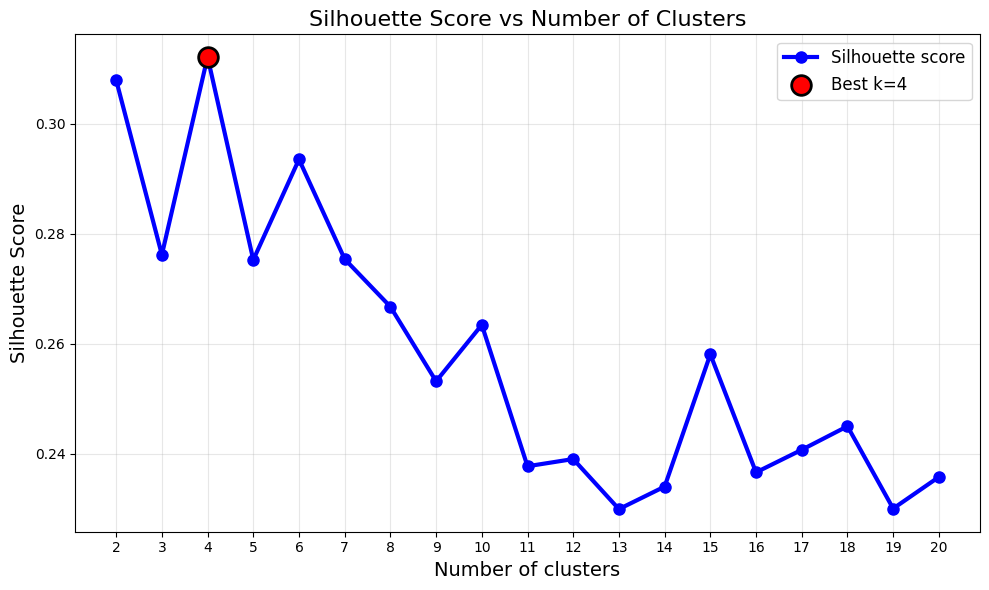

ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ С k=4

Кластеризация завершена!

Распределение по кластерам:
   Кластер 0: 159355 точек (38.3%)
   Кластер 1: 163812 точек (39.4%)
   Кластер 2: 85692 точек (20.6%)
   Кластер 3: 7294 точек (1.8%)

Центры кластеров (первые 5):
   Кластер 0: temp=21.82, hum=53.02, CO=141.92
   Кластер 1: temp=19.53, hum=53.30, CO=89.03
   Кластер 2: temp=21.02, hum=51.63, CO=112.94
   Кластер 3: temp=17.60, hum=49.43, CO=69.16


In [34]:
def evaluate_kmeans_silhouette(X, k_range=range(2, 21), sample_size=20000):
    print(f"АНАЛИЗ K-MEANS (только Silhouette)")
    print(f"Размер датасета: {len(X)} строк × {X.shape[1]} признаков")
    start_time = time.time()
    n_samples = min(sample_size, len(X))
    sample_idx = np.random.choice(len(X), n_samples, replace=False)
    if hasattr(X, 'iloc'):
        X_sample = X.iloc[sample_idx].values
        X_full = X.values if hasattr(X, 'values') else X
    else:
        X_sample = X[sample_idx]
        X_full = X
    print(f"Используем выборку {n_samples} точек для расчета метрик")
    best_k = 0
    best_silhouette = -1
    best_centers = None
    silhouette_scores = []
    for k in tqdm(list(k_range), desc="Анализ кластеров"):
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=min(1024, len(X)//20),
            max_iter=100,
            n_init=5,
            random_state=42
        )
        kmeans.fit(X_full)
        y_pred_full = kmeans.predict(X_full)
        y_pred_sample = y_pred_full[sample_idx]
        sil = metrics.silhouette_score(X_sample, y_pred_sample)
        silhouette_scores.append(sil)
        if sil > best_silhouette:
            best_silhouette = sil
            best_k = k
            best_centers = kmeans.cluster_centers_
        print(f"   k={k}: silhouette={sil:.4f}")
    elapsed = time.time() - start_time
    print(f"РЕЗУЛЬТАТЫ")
    print(f"Время выполнения: {elapsed:.1f} сек ({elapsed/60:.1f} мин)")
    print(f"\nЛучшее k = {best_k}")
    print(f"Silhouette score = {best_silhouette:.4f}")
    return best_k, best_silhouette, best_centers, silhouette_scores, list(k_range)
print("ЗАПУСК ОПТИМИЗИРОВАННОГО АНАЛИЗА...\n")
best_k, best_sil, centers, sil_scores, k_vals = evaluate_kmeans_silhouette(
    X=X,
    k_range=range(2, 21),
    sample_size=5000
)
plt.figure(figsize=(10, 6))
plt.plot(k_vals, sil_scores, 'bo-', linewidth=3, markersize=8, label='Silhouette score')
plt.scatter(best_k, best_sil, color='red', s=200, zorder=5,
            edgecolor='black', linewidth=2, label=f'Best k={best_k}')
plt.xlabel('Number of clusters', size=14)
plt.ylabel('Silhouette Score', size=14)
plt.title('Silhouette Score vs Number of Clusters', size=16)
plt.xticks(k_vals, size=10)
plt.yticks(size=10)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print(f"ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ С k={best_k}")
final_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=1024,
    max_iter=100,
    n_init=10,
    random_state=42
)
final_labels = final_kmeans.fit_predict(X)
print(f"\nКластеризация завершена!")
print(f"\nРаспределение по кластерам:")
unique, counts = np.unique(final_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    percentage = count / len(X) * 100
    print(f"   Кластер {cluster}: {count} точек ({percentage:.1f}%)")
print(f"\nЦентры кластеров (первые 5):")
for i, center in enumerate(centers[:5]):
    print(f"   Кластер {i}: temp={center[0]:.2f}, hum={center[1]:.2f}, CO={center[2]:.2f}")
if len(X) <= 10000:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    sample_size_display = min(2000, len(X))
    idx_display = np.random.choice(len(X), sample_size_display, replace=False)
    if hasattr(X, 'iloc'):
        X_display = X.iloc[idx_display]
    else:
        X_display = X[idx_display]
    labels_display = final_labels[idx_display]
    scatter = ax.scatter(
        X_display['temperature'] if hasattr(X_display, 'temperature') else X_display[:, 0],
        X_display['humidity'] if hasattr(X_display, 'humidity') else X_display[:, 1],
        X_display['COValue'] if hasattr(X_display, 'COValue') else X_display[:, 2],
        c=labels_display,
        cmap='viridis',
        s=30,
        alpha=0.7
    )
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Humidity')
    ax.set_zlabel('CO Value')
    ax.set_title(f'K-Means Clustering (k={best_k})')
    plt.colorbar(scatter)
    plt.show()

Дендрограмма.

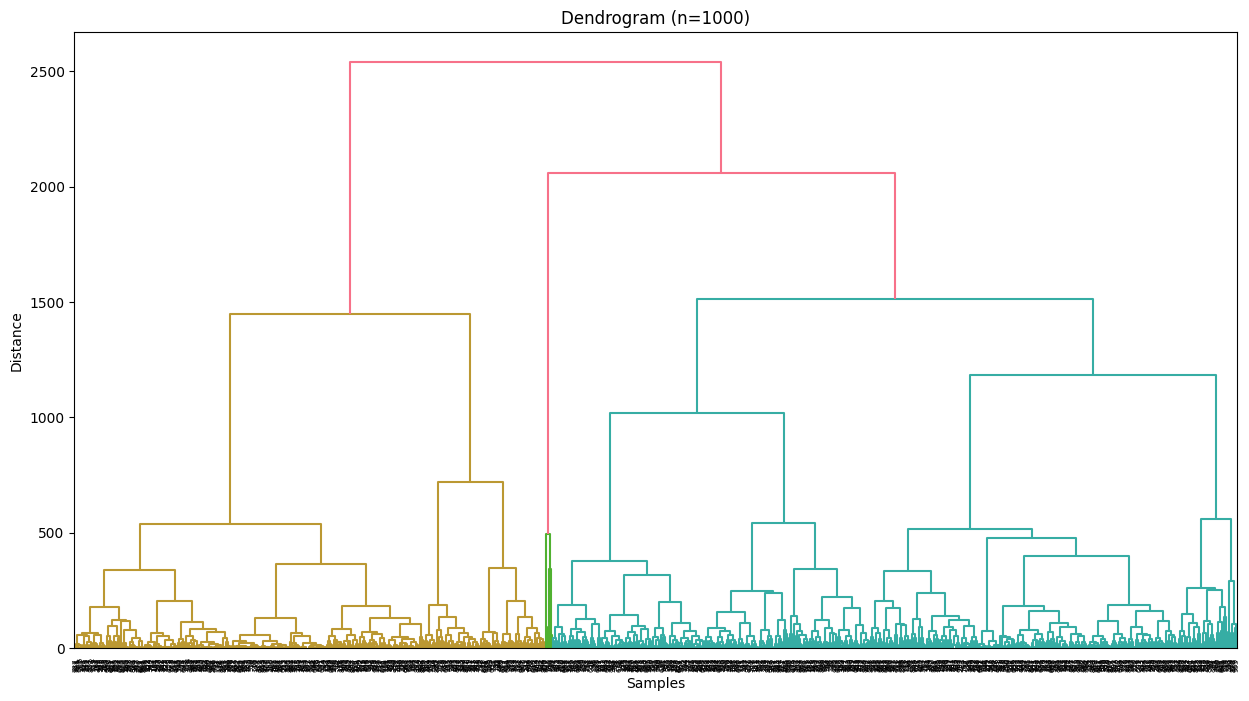

In [33]:
if 'df' in dir() and df is not None:
    data = df.values
else:
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns
    data = dataset[numeric_cols].values
sample_size = min(1000, len(data))
idx = np.random.choice(len(data), sample_size, replace=False)
data_sample = data[idx]
plt.figure(figsize=(15, 8))
mergings = linkage(data_sample, method='ward')
dendrogram(mergings, leaf_rotation=90, leaf_font_size=5)
plt.title(f'Dendrogram (n={sample_size})')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

DBSCAN.

['y', 'b', 'g', 'r']


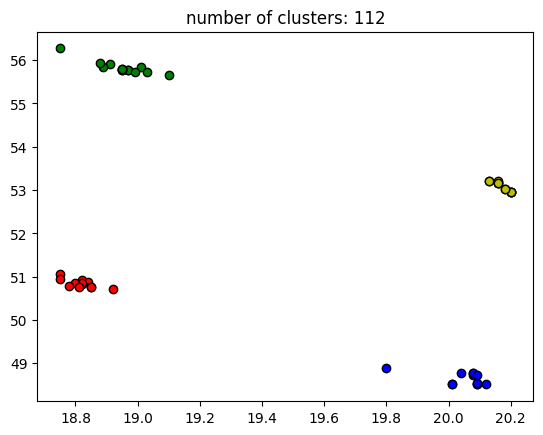

In [40]:
mins = X.shape[1]
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		col = 'k'
	class_member_mask = (labels == k)
	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["temperature"], xy["humidity"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)
	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["temperature"], xy["humidity"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)
plt.title('number of clusters: %d' % n_clusters_)
plt.show()

Отображаем 500 случайных точек из 416153


/tmp/ipykernel_16419/905929588.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


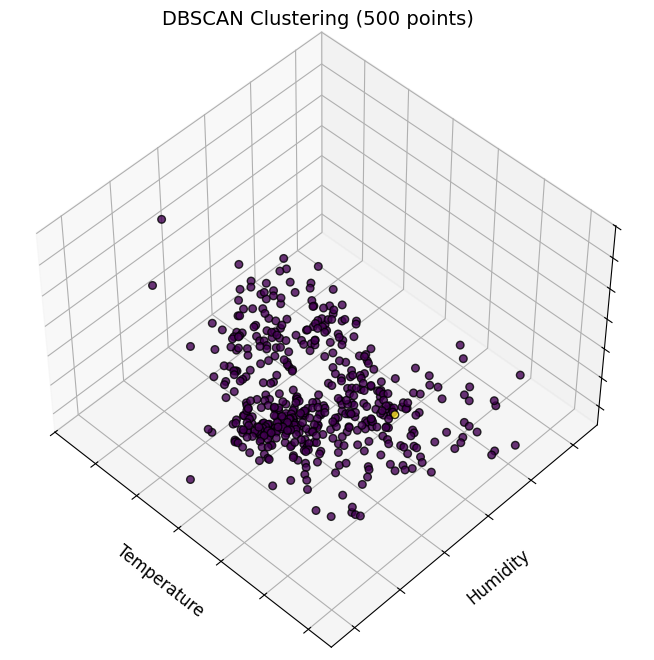


Статистика:
  Всего точек в датасете: 416153
  Отображено точек: 500 (0.1%)


In [37]:
MAX_POINTS = 500

if len(X) > MAX_POINTS:
    sample_idx = np.random.choice(len(X), MAX_POINTS, replace=False)
    if hasattr(X, 'iloc'):
        X_sample = X.iloc[sample_idx]
    else:
        X_sample = X[sample_idx]
    labels_sample = labels[sample_idx]
    print(f"Отображаем {MAX_POINTS} случайных точек из {len(X)}")
else:
    X_sample = X
    labels_sample = labels
    print(f"Отображаем все {len(X)} точек")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)
scatter = ax.scatter(
    X_sample["temperature"] if hasattr(X_sample, 'temperature') else X_sample[:, 0],
    X_sample["humidity"] if hasattr(X_sample, 'humidity') else X_sample[:, 1],
    X_sample["COValue"] if hasattr(X_sample, 'COValue') else X_sample[:, 2],
    c=labels_sample.astype(float),
    edgecolor="k",
    s=30,
    alpha=0.8,
    cmap='viridis'
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Temperature", fontsize=12)
ax.set_ylabel("Humidity", fontsize=12)
ax.set_zlabel("CO Value", fontsize=12)
ax.set_title(f"DBSCAN Clustering ({len(X_sample)} points)", fontsize=14)
plt.tight_layout()
plt.show()
print(f"\nСтатистика:")
print(f"  Всего точек в датасете: {len(X)}")
print(f"  Отображено точек: {len(X_sample)} ({len(X_sample)/len(X)*100:.1f}%)")

In [39]:
sample_size = 5000
print(f"Оценка на {sample_size} точках...")
np.random.seed(42)
idx = np.random.choice(len(X), sample_size, replace=False)
X_small = X.iloc[idx]
labels_small = labels[idx]
sil = metrics.silhouette_score(X_small, labels_small)
print(f"Silhouette: {sil:.4f}")
if y is not None:
    y_small = y[idx]
    ari = metrics.adjusted_rand_score(y_small, labels_small)
    print(f"ARI: {ari:.4f}")

Оценка на 5000 точках...
Silhouette: -0.4469
ARI: 0.0000
